In [7]:
#Importando bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# Carregando os 3 datasets do projeto

# Preços diários de petróleo e gás durante a guerra
df_oil = pd.read_csv('iran_war_oil_prices_daily_2026.csv')

# Preços de combustível por estado americano
df_gas = pd.read_csv('iran_war_gas_prices_by_state.csv')

# Linha do tempo dos eventos-chave da guerra
df_events = pd.read_csv('iran_war_key_events_timeline.csv')

# Verificando se os arquivos carregaram corretamente
print(f"Oil prices:   {df_oil.shape[0]} linhas, {df_oil.shape[1]} colunas")
print(f"Gas by state: {df_gas.shape[0]} linhas, {df_gas.shape[1]} colunas")
print(f"Key events:   {df_events.shape[0]} linhas, {df_events.shape[1]} colunas")

Oil prices:   24 linhas, 16 colunas
Gas by state: 50 linhas, 9 colunas
Key events:   11 linhas, 7 colunas


In [9]:
# Inspecionando o dataset principal — preços diários de petróleo

# Visualizando as primeiras 5 linhas
print("Primeiras 5 linhas:")
display(df_oil.head())

# Verificando o tipo de dado de cada coluna
print("\nTipos de dados:")
print(df_oil.dtypes)

Primeiras 5 linhas:


,date,brent_usd_barrel,wti_usd_barrel,dubai_usd_barrel,us_gas_avg_gallon,us_diesel_avg_gallon,strait_hormuz_daily_ships,iran_production_mbpd,key_event,war_day,brent_vs_prewar_pct,gas_vs_prewar_pct,gas_change_from_prewar_dollars,phase,source,data_as_of
0,2026-02-09,67.4,62.1,66.8,2.81,3.68,138,3.3,Trump-Iran diplomatic talks described as 'very...,-19,-7.8,-5.7,-0.17,Pre-War Tensions,AAA/CNBC/Fortune/NPR/CBS/Reuters/Euronews veri...,"March 20, 2026"
1,2026-02-10,69.3,64.2,68.4,2.83,3.70,138,3.3,US warns ships to avoid Iranian waters during ...,-18,-5.2,-5.0,-0.15,Pre-War Tensions,AAA/CNBC/Fortune/NPR/CBS/Reuters/Euronews veri...,"March 20, 2026"
2,2026-02-14,71.2,65.8,70.1,2.84,3.71,138,3.3,Iran insists on maintaining uranium enrichment,-14,-2.6,-4.7,-0.14,Pre-War Tensions,AAA/CNBC/Fortune/NPR/CBS/Reuters/Euronews veri...,"March 20, 2026"
3,2026-02-18,72.8,67.4,71.8,2.85,3.72,138,3.3,US-Israel joint military exercises escalate te...,-10,-0.4,-4.4,-0.13,Pre-War Tensions,AAA/CNBC/Fortune/NPR/CBS/Reuters/Euronews veri...,"March 20, 2026"
4,2026-02-24,71.5,66.2,70.4,2.87,3.74,138,3.2,Final diplomatic ultimatum issued to Iran,-4,-2.2,-3.7,-0.11,Pre-War Tensions,AAA/CNBC/Fortune/NPR/CBS/Reuters/Euronews veri...,"March 20, 2026"



Tipos de dados:
date                               object
brent_usd_barrel                  float64
wti_usd_barrel                    float64
dubai_usd_barrel                  float64
us_gas_avg_gallon                 float64
us_diesel_avg_gallon              float64
strait_hormuz_daily_ships           int64
iran_production_mbpd              float64
key_event                          object
war_day                             int64
brent_vs_prewar_pct               float64
gas_vs_prewar_pct                 float64
gas_change_from_prewar_dollars    float64
phase                              object
source                             object
data_as_of                         object
dtype: object


In [10]:
# Inspecionando o dataset de preços por estado

print("Primeiras 5 linhas — Gas by State:")
display(df_gas.head())

print("\nTipos de dados — Gas by State:")
print(df_gas.dtypes)

print("\n" + "="*50)

# Inspecionando o dataset de eventos
print("\nTodos os eventos registrados:")
display(df_events)

print("\nTipos de dados — Key Events:")
print(df_events.dtypes)

Primeiras 5 linhas — Gas by State:


,state,region,gas_price_mar19_2026,gas_price_prewar_feb27,gas_price_jan08_2026,price_increase_since_war,pct_increase_since_war,price_vs_national_avg,source
0,California,West,5.53,4.52,3.88,1.01,22.3,1.65,"AAA State Gas Price Averages — March 19, 2026"
1,Washington,West,5.15,4.18,3.42,0.97,23.2,1.27,"AAA State Gas Price Averages — March 19, 2026"
2,Hawaii,West,5.07,4.02,3.78,1.05,26.1,1.19,"AAA State Gas Price Averages — March 19, 2026"
3,Oregon,West,4.70,3.82,3.22,0.88,23.0,0.82,"AAA State Gas Price Averages — March 19, 2026"
4,Nevada,West,4.66,3.72,3.18,0.94,25.3,0.78,"AAA State Gas Price Averages — March 19, 2026"



Tipos de dados — Gas by State:
state                        object
region                       object
gas_price_mar19_2026        float64
gas_price_prewar_feb27      float64
gas_price_jan08_2026        float64
price_increase_since_war    float64
pct_increase_since_war      float64
price_vs_national_avg       float64
source                       object
dtype: object


Todos os eventos registrados:


,date,event_title,description,war_day,category,brent_price_that_day,source
0,2026-02-28,War Begins,US-Israel launch joint airstrikes on Iran nucl...,1,Conflict Start,79.50,CNBC/Fortune/Reuters/Euronews/NPR/IEA verified
1,2026-03-02,Qatar LNG Shutdown,Iran drone attacks on Ras Laffan force Qatar t...,3,Energy Infrastructure,87.60,CNBC/Fortune/Reuters/Euronews/NPR/IEA verified
2,2026-03-04,IEA Emergency Release,IEA announces 400M barrel release — largest in...,5,Policy Response,91.98,CNBC/Fortune/Reuters/Euronews/NPR/IEA verified
3,2026-03-07,Dubai Crude Record,Dubai crude hits all-time high above $150/barr...,8,Price Record,96.80,CNBC/Fortune/Reuters/Euronews/NPR/IEA verified
4,2026-03-10,Brent Crosses $100,Brent above $100 for first time since 2022. Ga...,11,Price Milestone,99.80,CNBC/Fortune/Reuters/Euronews/NPR/IEA verified
5,2026-03-13,Sanctioned Oil Released,US allows sanctioned Iranian tanker crude into...,14,Policy Response,103.20,CNBC/Fortune/Reuters/Euronews/NPR/IEA verified
6,2026-03-15,Kharg Island Strike,Trump orders strikes on Iranian military asset...,16,Military Escalation,100.20,CNBC/Fortune/Reuters/Euronews/NPR/IEA verified
7,2026-03-18,South Pars Attack,Israel strikes South Pars — Iran's largest gas...,19,Energy Infrastructure,108.65,CNBC/Fortune/Reuters/Euronews/NPR/IEA verified
8,2026-03-18,Qatar 17% LNG Offline,Iranian missile strikes take out 17% of Qatar'...,19,Energy Infrastructure,108.65,CNBC/Fortune/Reuters/Euronews/NPR/IEA verified
9,2026-03-19,Brent Hits $119,Brent briefly touches $119 intraday high. Isra...,20,Price Record,108.65,CNBC/Fortune/Reuters/Euronews/NPR/IEA verified



Tipos de dados — Key Events:
date                     object
event_title              object
description              object
war_day                   int64
category                 object
brent_price_that_day    float64
source                   object
dtype: object


In [11]:
# Verificando valores nulos em todos os datasets

print("Valores nulos — Oil Prices:")
print(df_oil.isnull().sum())

print("\nValores nulos — Gas by State:")
print(df_gas.isnull().sum())

print("\nValores nulos — Key Events:")
print(df_events.isnull().sum())

Valores nulos — Oil Prices:
date                              0
brent_usd_barrel                  0
wti_usd_barrel                    0
dubai_usd_barrel                  0
us_gas_avg_gallon                 0
us_diesel_avg_gallon              0
strait_hormuz_daily_ships         0
iran_production_mbpd              0
key_event                         0
war_day                           0
brent_vs_prewar_pct               0
gas_vs_prewar_pct                 0
gas_change_from_prewar_dollars    0
phase                             0
source                            0
data_as_of                        0
dtype: int64

Valores nulos — Gas by State:
state                       0
region                      0
gas_price_mar19_2026        0
gas_price_prewar_feb27      0
gas_price_jan08_2026        0
price_increase_since_war    0
pct_increase_since_war      0
price_vs_national_avg       0
source                      0
dtype: int64

Valores nulos — Key Events:
date                    0
event_title   

In [12]:
# Verificando linhas duplicadas em todos os datasets

print(f"Duplicatas — Oil Prices:   {df_oil.duplicated().sum()}")
print(f"Duplicatas — Gas by State: {df_gas.duplicated().sum()}")
print(f"Duplicatas — Key Events:   {df_events.duplicated().sum()}")

Duplicatas — Oil Prices:   0
Duplicatas — Gas by State: 0
Duplicatas — Key Events:   0


In [13]:
# Resumo estatístico do dataset principal

print("Resumo estatístico — Oil Prices:")
display(df_oil.describe().round(2))

Resumo estatístico — Oil Prices:


,brent_usd_barrel,wti_usd_barrel,dubai_usd_barrel,us_gas_avg_gallon,us_diesel_avg_gallon,strait_hormuz_daily_ships,iran_production_mbpd,war_day,brent_vs_prewar_pct,gas_vs_prewar_pct,gas_change_from_prewar_dollars
count,24.00,24.00,24.00,24.00,24.00,24.00,24.00,24.00,24.00,24.00,24.00
mean,91.19,83.62,90.55,3.33,4.27,38.21,2.35,5.79,24.75,11.85,0.35
std,14.10,12.31,14.42,0.38,0.51,58.88,0.61,11.93,19.29,12.77,0.38
min,67.40,62.10,66.80,2.81,3.68,4.00,1.60,-19.00,-7.80,-5.70,-0.17
25%,77.90,71.47,76.85,2.96,3.76,4.00,1.90,0.50,6.60,-0.50,-0.02
50%,94.60,87.85,93.70,3.32,4.12,5.00,2.15,7.00,29.40,11.25,0.34
75%,101.50,93.88,100.65,3.64,4.73,43.50,2.90,15.25,38.85,21.98,0.66
max,110.30,96.20,112.10,3.92,5.10,138.00,3.30,21.00,50.90,31.50,0.94


In [14]:
# Verificando o período temporal coberto pelo dataset

print("Período coberto — Oil Prices:")
print(f"  Data inicial: {df_oil['date'].min()}")
print(f"  Data final:   {df_oil['date'].max()}")
print(f"  Total de registros: {len(df_oil)}")

print("\nFases presentes no dataset:")
print(df_oil['phase'].value_counts())

Período coberto — Oil Prices:
  Data inicial: 2026-02-09
  Data final:   2026-03-20
  Total de registros: 24

Fases presentes no dataset:
phase
Week 3 Infrastructure Strikes (Mar 14-21)    7
Pre-War Tensions                             6
Week 1 Shock (Feb 28 - Mar 6)                6
Week 2 Escalation (Mar 7-13)                 5
Name: count, dtype: int64


In [17]:
# ============================================================
# DIAGNÓSTICO FINAL DA EDA
# ============================================================

print("=" * 55)
print("O QUE ENCONTRAMOS NA EDA")
print("=" * 55)

print("""
PROBLEMAS IDENTIFICADOS PARA A FASE 3 (LIMPEZA):

[1] Coluna 'date' nos 3 datasets
    → Tipo atual:    object 
    → Tipo correto:  datetime
    → Impacto:       sem isso não conseguimos plotar
                     gráficos no eixo do tempo

[2] Colunas 'source' e 'data_as_of' no df_oil
    → São metadados de verificação da fonte
    → Não contribuem com nenhuma análise
    → Serão removidas

[3] Coluna 'source' no df_gas e df_events
    → Mesmo caso — metadado, será removida

[4] Coluna 'key_event' no df_oil
    → Textos inconsistentes
    → Será substituída pela coluna 'event_title'
      do df_events via merge por data

O QUE ESTÁ OK:
  ✓ Zero valores nulos nos 3 datasets
  ✓ Zero duplicatas nos 3 datasets
  ✓ Todas as colunas numéricas com tipo correto
  ✓ 24 registros cobrindo 4 fases da guerra
  ✓ Valores dentro do esperado
""")

O QUE ENCONTRAMOS NA EDA

PROBLEMAS IDENTIFICADOS PARA A FASE 3 (LIMPEZA):

[1] Coluna 'date' nos 3 datasets
    → Tipo atual:    object 
    → Tipo correto:  datetime
    → Impacto:       sem isso não conseguimos plotar
                     gráficos no eixo do tempo

[2] Colunas 'source' e 'data_as_of' no df_oil
    → São metadados de verificação da fonte
    → Não contribuem com nenhuma análise
    → Serão removidas

[3] Coluna 'source' no df_gas e df_events
    → Mesmo caso — metadado, será removida

[4] Coluna 'key_event' no df_oil
    → Textos inconsistentes
    → Será substituída pela coluna 'event_title'
      do df_events via merge por data

O QUE ESTÁ OK:
  ✓ Zero valores nulos nos 3 datasets
  ✓ Zero duplicatas nos 3 datasets
  ✓ Todas as colunas numéricas com tipo correto
  ✓ 24 registros cobrindo 4 fases da guerra
  ✓ Valores dentro do esperado



In [16]:
# ============================================================
# FASE 3 — LIMPEZA E PRÉ-PROCESSAMENTO
# ============================================================

# Criando cópias dos datasets originais antes de qualquer alteração

oil = df_oil.copy()
gas = df_gas.copy()
events = df_events.copy()

print("Cópias criadas com sucesso!")
print(f"  oil:    {oil.shape}")
print(f"  gas:    {gas.shape}")
print(f"  events: {events.shape}")

Cópias criadas com sucesso!
  oil:    (24, 16)
  gas:    (50, 9)
  events: (11, 7)


In [18]:
# Removendo colunas que não contribuem com a análise
oil = oil.drop(columns=['source', 'data_as_of'])

gas = gas.drop(columns=['source'])
events = events.drop(columns=['source'])

# Confirmando as novas dimensões
print(f"oil:    {oil.shape}    (era 16 colunas, agora {oil.shape[1]})")
print(f"gas:    {gas.shape}   (era 9 colunas, agora {gas.shape[1]})")
print(f"events: {events.shape}  (era 7 colunas, agora {events.shape[1]})")

oil:    (24, 14)    (era 16 colunas, agora 14)
gas:    (50, 8)   (era 9 colunas, agora 8)
events: (11, 6)  (era 7 colunas, agora 6)


In [14]:
# Convertendo a coluna 'date' de texto para datetime nos 3 datasets

oil['date'] = pd.to_datetime(oil['date'])
gas_prewar_date = pd.to_datetime('2026-02-27')  # Data de referência pré-guerra
events['date'] = pd.to_datetime(events['date'])

# Confirmando a conversão
print("Tipos da coluna date após conversão:")
print(f"  oil:    {oil['date'].dtype}")
print(f"  events: {events['date'].dtype}")

print(f"\nPeríodo do dataset principal:")
print(f"  De: {oil['date'].min().strftime('%d/%m/%Y')}")
print(f"  Até: {oil['date'].max().strftime('%d/%m/%Y')}")

Tipos da coluna date após conversão:
  oil:    datetime64[ns]
  events: datetime64[ns]

Período do dataset principal:
  De: 09/02/2026
  Até: 20/03/2026


In [19]:
# A coluna 'key_event' do dataset principal tem textos longos e inconsistentes
# Vamos substituí-la por uma versão limpa usando o df_events como referência

oil = oil.drop(columns=['key_event'])

# Trazendo apenas date e event_title do dataset de eventos
eventos_limpos = events[['date', 'event_title']]

# Unindo os dois datasets pela coluna date
oil = oil.merge(eventos_limpos, on='date', how='left')

# Confirmando o resultado
print("Colunas do oil após merge:")
print(oil.columns.tolist())

print(f"\nDias com evento registrado: {oil['event_title'].notna().sum()}")
print(f"Dias sem evento:            {oil['event_title'].isna().sum()}")

Colunas do oil após merge:
['date', 'brent_usd_barrel', 'wti_usd_barrel', 'dubai_usd_barrel', 'us_gas_avg_gallon', 'us_diesel_avg_gallon', 'strait_hormuz_daily_ships', 'iran_production_mbpd', 'war_day', 'brent_vs_prewar_pct', 'gas_vs_prewar_pct', 'gas_change_from_prewar_dollars', 'phase', 'event_title']

Dias com evento registrado: 11
Dias sem evento:            14


In [17]:
# Confirmando que o dataset está limpo e pront o

print("=" * 55)
print("VERIFICAÇÃO FINAL — DATASET LIMPO")
print("=" * 55)

print(f"\nDimensões finais:")
print(f"  oil:    {oil.shape}")
print(f"  gas:    {gas.shape}")
print(f"  events: {events.shape}")

print(f"\nTipos de dados — oil:")
print(oil.dtypes)

print(f"\nPrimeiras 3 linhas do oil limpo:")
display(oil.head(3))

VERIFICAÇÃO FINAL — DATASET LIMPO

Dimensões finais:
  oil:    (25, 14)
  gas:    (50, 8)
  events: (11, 6)

Tipos de dados — oil:
date                              datetime64[ns]
brent_usd_barrel                         float64
wti_usd_barrel                           float64
dubai_usd_barrel                         float64
us_gas_avg_gallon                        float64
us_diesel_avg_gallon                     float64
strait_hormuz_daily_ships                  int64
iran_production_mbpd                     float64
war_day                                    int64
brent_vs_prewar_pct                      float64
gas_vs_prewar_pct                        float64
gas_change_from_prewar_dollars           float64
phase                                     object
event_title                               object
dtype: object

Primeiras 3 linhas do oil limpo:


,date,brent_usd_barrel,wti_usd_barrel,dubai_usd_barrel,us_gas_avg_gallon,us_diesel_avg_gallon,strait_hormuz_daily_ships,iran_production_mbpd,war_day,brent_vs_prewar_pct,gas_vs_prewar_pct,gas_change_from_prewar_dollars,phase,event_title
0,2026-02-09,67.4,62.1,66.8,2.81,3.68,138,3.3,-19,-7.8,-5.7,-0.17,Pre-War Tensions,NaN
1,2026-02-10,69.3,64.2,68.4,2.83,3.70,138,3.3,-18,-5.2,-5.0,-0.15,Pre-War Tensions,NaN
2,2026-02-14,71.2,65.8,70.1,2.84,3.71,138,3.3,-14,-2.6,-4.7,-0.14,Pre-War Tensions,NaN


In [18]:
# O dataset tinha 24 linhas e agora tem 25

print("Datas duplicadas no oil após merge:")
print(oil[oil.duplicated(subset='date', keep=False)])

Datas duplicadas no oil após merge:
         date  brent_usd_barrel  wti_usd_barrel  dubai_usd_barrel  \
21 2026-03-18            108.65            96.1             107.4   
22 2026-03-18            108.65            96.1             107.4   

    us_gas_avg_gallon  us_diesel_avg_gallon  strait_hormuz_daily_ships  \
21               3.84                  5.02                          4   
22               3.84                  5.02                          4   

    iran_production_mbpd  war_day  brent_vs_prewar_pct  gas_vs_prewar_pct  \
21                   1.7       19                 48.6               28.9   
22                   1.7       19                 48.6               28.9   

    gas_change_from_prewar_dollars                                      phase  \
21                            0.86  Week 3 Infrastructure Strikes (Mar 14-21)   
22                            0.86  Week 3 Infrastructure Strikes (Mar 14-21)   

              event_title  
21      South Pars Attack  
2

In [20]:
# Problema: dia 18/03 tem 2 eventos, gerando linha duplicada no merge

# Agrupando eventos por data 
eventos_limpos = (
    events.groupby('date')['event_title']
    .apply(lambda x: ' | '.join(x))
    .reset_index()
)

# Removendo a coluna event_title que veio errada do merge anterior
oil = oil.drop(columns=['event_title'])

# Removendo a linha duplicada que havia sobrado
oil = oil.drop_duplicates(subset='date')

# Refazendo o merge com os eventos agrupados
oil = oil.merge(eventos_limpos, on='date', how='left')

# Confirmando que voltou para 24 linhas
print(f"Linhas no oil: {len(oil)} (esperado: 24)")

# Verificando como ficou o dia 18/03
print("\nEvento do dia 18/03:")
print(oil[oil['date'] == '2026-03-18']['event_title'].values)

Linhas no oil: 24 (esperado: 24)

Evento do dia 18/03:
['South Pars Attack | Qatar 17% LNG Offline']


In [21]:
# ============================================================
# LMPEZA CONCLUÍDA
# ============================================================

print("=" * 55)
print("LIMPEZA CONCLUÍDA")
print("=" * 55)

print("""
[1] Colunas inúteis removidas
    → 'source' removida dos 3 datasets
    → 'data_as_of' removida do oil
    → oil: 16 → 14 colunas

[2] Coluna 'date' convertida para datetime
    → oil e events: object → datetime64[ns]
    → Agora podemos plotar eixo do tempo corretamente

[3] Coluna 'key_event' substituída por 'event_title'
    → Textos longos removidos
    → Eventos limpos trazidos via merge com df_events
    → Dois eventos no mesmo dia combinados com ' | '

[4] Linha duplicada corrigida
    → Merge inicial gerou 25 linhas por causa do dia 18/03
    → Problema identificado, investigado e corrigido

DATASETS PRONTOS PARA A FASE 4:
  oil:    24 linhas, 14 colunas  ✓
  gas:    50 linhas,  8 colunas  ✓
  events: 11 linhas,  6 colunas  ✓
""")

LIMPEZA CONCLUÍDA

[1] Colunas inúteis removidas
    → 'source' removida dos 3 datasets
    → 'data_as_of' removida do oil
    → oil: 16 → 14 colunas

[2] Coluna 'date' convertida para datetime
    → oil e events: object → datetime64[ns]
    → Agora podemos plotar eixo do tempo corretamente

[3] Coluna 'key_event' substituída por 'event_title'
    → Textos longos removidos
    → Eventos limpos trazidos via merge com df_events
    → Dois eventos no mesmo dia combinados com ' | '

[4] Linha duplicada corrigida
    → Merge inicial gerou 25 linhas por causa do dia 18/03
    → Problema identificado, investigado e corrigido

DATASETS PRONTOS PARA A FASE 4:
  oil:    24 linhas, 14 colunas  ✓
  gas:    50 linhas,  8 colunas  ✓
  events: 11 linhas,  6 colunas  ✓



In [21]:
# ============================================================
#  ENGENHARIA DE ATRIBUTOS
# ============================================================

# [1] Variação percentual diária do Brent
oil['brent_daily_change_pct'] = (oil['brent_usd_barrel'].pct_change() * 100).round(2)

# Verificando o resultado
print("Variação diária do Brent (primeiros 5 dias):")
print(oil[['date', 'brent_usd_barrel', 'brent_daily_change_pct']].head(5))

Variação diária do Brent (primeiros 5 dias):
        date  brent_usd_barrel  brent_daily_change_pct
0 2026-02-09              67.4                     NaN
1 2026-02-10              69.3                    2.82
2 2026-02-14              71.2                    2.74
3 2026-02-18              72.8                    2.25
4 2026-02-24              71.5                   -1.79


In [22]:
# [2] Média móvel de 7 dias do Brent

oil['brent_ma7'] = oil['brent_usd_barrel'].rolling(window=7, min_periods=1).mean().round(2)

# Verificando o resultado
print("Média móvel de 7 dias — comparando com o preço diário:")
print(oil[['date', 'brent_usd_barrel', 'brent_ma7']].to_string())

Média móvel de 7 dias — comparando com o preço diário:
          date  brent_usd_barrel  brent_ma7
0   2026-02-09             67.40      67.40
1   2026-02-10             69.30      68.35
2   2026-02-14             71.20      69.30
3   2026-02-18             72.80      70.18
4   2026-02-24             71.50      70.44
5   2026-02-27             73.10      70.88
6   2026-02-28             79.50      72.11
7   2026-03-01             84.20      74.51
8   2026-03-02             87.60      77.13
9   2026-03-03             91.20      79.99
10  2026-03-04             91.98      82.73
11  2026-03-05             92.40      85.71
12  2026-03-07             96.80      89.10
13  2026-03-10             99.80      92.00
14  2026-03-11            100.20      94.28
15  2026-03-12            101.40      96.25
16  2026-03-13            103.20      97.97
17  2026-03-14            101.80      99.37
18  2026-03-15            100.20     100.49
19  2026-03-16            100.80     101.06
20  2026-03-17       

In [23]:
# [3] Volatilidade rolling de 5 dias

oil['brent_volatility_5d'] = oil['brent_usd_barrel'].rolling(window=5, min_periods=2).std().round(2)

# Verificando os dias de maior volatilidade
print("Top 5 dias de maior volatilidade:")
print(oil[['date', 'brent_usd_barrel', 'brent_daily_change_pct', 'brent_volatility_5d']]
      .sort_values('brent_volatility_5d', ascending=False)
      .head(5)
      .to_string())

Top 5 dias de maior volatilidade:
         date  brent_usd_barrel  brent_daily_change_pct  brent_volatility_5d
9  2026-03-03             91.20                    4.11                 7.07
8  2026-03-02             87.60                    4.04                 6.93
7  2026-03-01             84.20                    5.91                 5.43
10 2026-03-04             91.98                    0.86                 5.17
22 2026-03-19            108.65                    0.00                 4.08


In [24]:
# [4] Mapeando cores para cada fase

cores_fase = {
    'Pre-War Tensions'                          : '#3498DB',  # Azul
    'Week 1 Shock (Feb 28 - Mar 6)'             : '#E74C3C',  # Vermelho
    'Week 2 Escalation (Mar 7-13)'              : '#E67E22',  # Laranja
    'Week 3 Infrastructure Strikes (Mar 14-21)' : '#8E44AD'   # Roxo
}

oil['phase_color'] = oil['phase'].map(cores_fase)

# Confirmando o mapeamento
print("Cores mapeadas por fase:")
print(oil[['phase', 'phase_color']].drop_duplicates().to_string())

Cores mapeadas por fase:
                                        phase phase_color
0                            Pre-War Tensions     #3498DB
6               Week 1 Shock (Feb 28 - Mar 6)     #E74C3C
12               Week 2 Escalation (Mar 7-13)     #E67E22
17  Week 3 Infrastructure Strikes (Mar 14-21)     #8E44AD


In [23]:
# ============================================================
# ENGENHARIA DE ATRIBUTOS CONCLUIDA
# ============================================================

print("=" * 55)
print("ENGENHARIA DE ATRIBUTOS — O QUE FOI CRIADO")
print("=" * 55)

print("""
[1] brent_daily_change_pct
    → Variação percentual do Brent dia a dia
    → Revela os dias de maior movimento do mercado

[2] brent_ma7
    → Média móvel de 7 dias
    → Mostra a tendência real ignorando o ruído diário

[3] brent_volatility_5d
    → Desvio padrão dos últimos 5 dias
    → Identifica os períodos de maior instabilidade
    → Semana 1 (01-04/03) foi a mais volátil do período

[4] phase_color
    → Cor consistente para cada fase da guerra
    → Garante padronização visual em todos os gráficos

INSIGHT IDENTIFICADO:
    Os 4 dias de maior volatilidade foram todos na
    Semana 1 — quando o Estreito fechou e o mercado
    ainda não sabia a dimensão do choque.
""")

print("Colunas finais do dataset oil:")
print(oil.columns.tolist())

ENGENHARIA DE ATRIBUTOS — O QUE FOI CRIADO

[1] brent_daily_change_pct
    → Variação percentual do Brent dia a dia
    → Revela os dias de maior movimento do mercado

[2] brent_ma7
    → Média móvel de 7 dias
    → Mostra a tendência real ignorando o ruído diário

[3] brent_volatility_5d
    → Desvio padrão dos últimos 5 dias
    → Identifica os períodos de maior instabilidade
    → Semana 1 (01-04/03) foi a mais volátil do período

[4] phase_color
    → Cor consistente para cada fase da guerra
    → Garante padronização visual em todos os gráficos

INSIGHT IDENTIFICADO:
    Os 4 dias de maior volatilidade foram todos na
    Semana 1 — quando o Estreito fechou e o mercado
    ainda não sabia a dimensão do choque.

Colunas finais do dataset oil:
['date', 'brent_usd_barrel', 'wti_usd_barrel', 'dubai_usd_barrel', 'us_gas_avg_gallon', 'us_diesel_avg_gallon', 'strait_hormuz_daily_ships', 'iran_production_mbpd', 'war_day', 'brent_vs_prewar_pct', 'gas_vs_prewar_pct', 'gas_change_from_prewar_

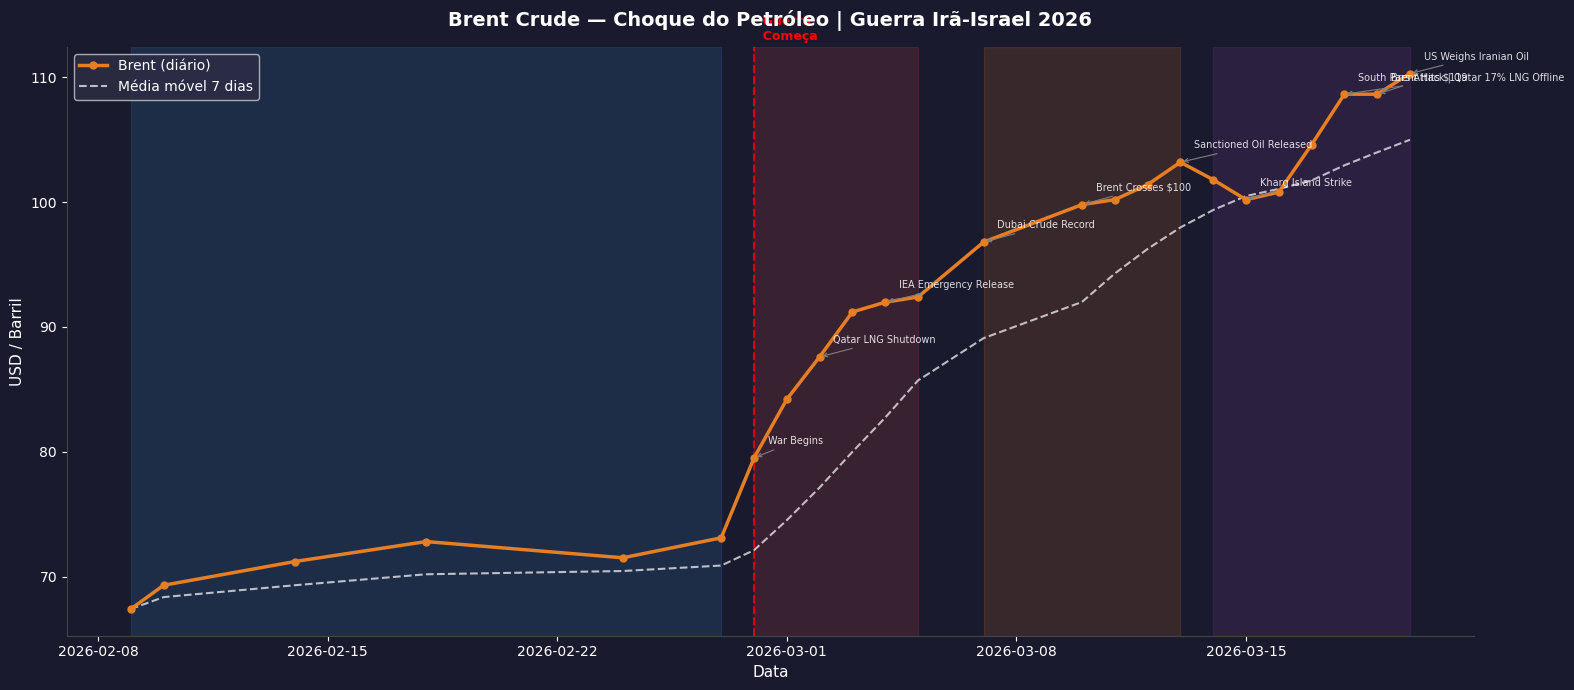

Gráfico 1 salvo!


In [26]:
# ============================================================
# FASE 5 — VISUALIZAÇÕES
# ============================================================

# GRÁFICO 1 — Linha do tempo do Brent com eventos marcados
# Responde: como o preço evoluiu e o que causou cada movimento?

fig, ax = plt.subplots(figsize=(16, 7))

# Plotando o preço diário do Brent
ax.plot(oil['date'], oil['brent_usd_barrel'],
        color='#E67E22', linewidth=2.5,
        marker='o', markersize=5, label='Brent (diário)', zorder=3)

# Plotando a média móvel de 7 dias por cima
ax.plot(oil['date'], oil['brent_ma7'],
        color='white', linewidth=1.5,
        linestyle='--', alpha=0.7, label='Média móvel 7 dias', zorder=2)

# Colorindo o fundo por fase
fases = oil.groupby('phase')
for fase, grupo in fases:
    ax.axvspan(grupo['date'].min(), grupo['date'].max(),
               alpha=0.15, color=grupo['phase_color'].iloc[0])

# Linha vertical marcando o início da guerra
ax.axvline(x=pd.Timestamp('2026-02-28'), color='red',
           linestyle='--', linewidth=1.5, alpha=0.8)
ax.text(pd.Timestamp('2026-02-28'), 113,
        '  Guerra\n  Começa', color='red', fontsize=9, fontweight='bold')

# Anotando os eventos principais
eventos_grafico = oil[oil['event_title'].notna()][['date', 'brent_usd_barrel', 'event_title']]
for _, row in eventos_grafico.iterrows():
    ax.annotate(row['event_title'],
                xy=(row['date'], row['brent_usd_barrel']),
                xytext=(10, 10), textcoords='offset points',
                fontsize=7, color='white', alpha=0.85,
                arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

# Configurações visuais
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.spines['bottom'].set_color('#444')
ax.spines['left'].set_color('#444')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_title('Brent Crude — Choque do Petróleo | Guerra Irã-Israel 2026',
             fontsize=14, fontweight='bold', color='white', pad=15)
ax.set_xlabel('Data', fontsize=11)
ax.set_ylabel('USD / Barril', fontsize=11)
ax.legend(facecolor='#2d2d44', labelcolor='white', fontsize=10)

plt.tight_layout()
plt.savefig('grafico1_brent_timeline.png', dpi=150,
            bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

print("Gráfico 1 salvo!")

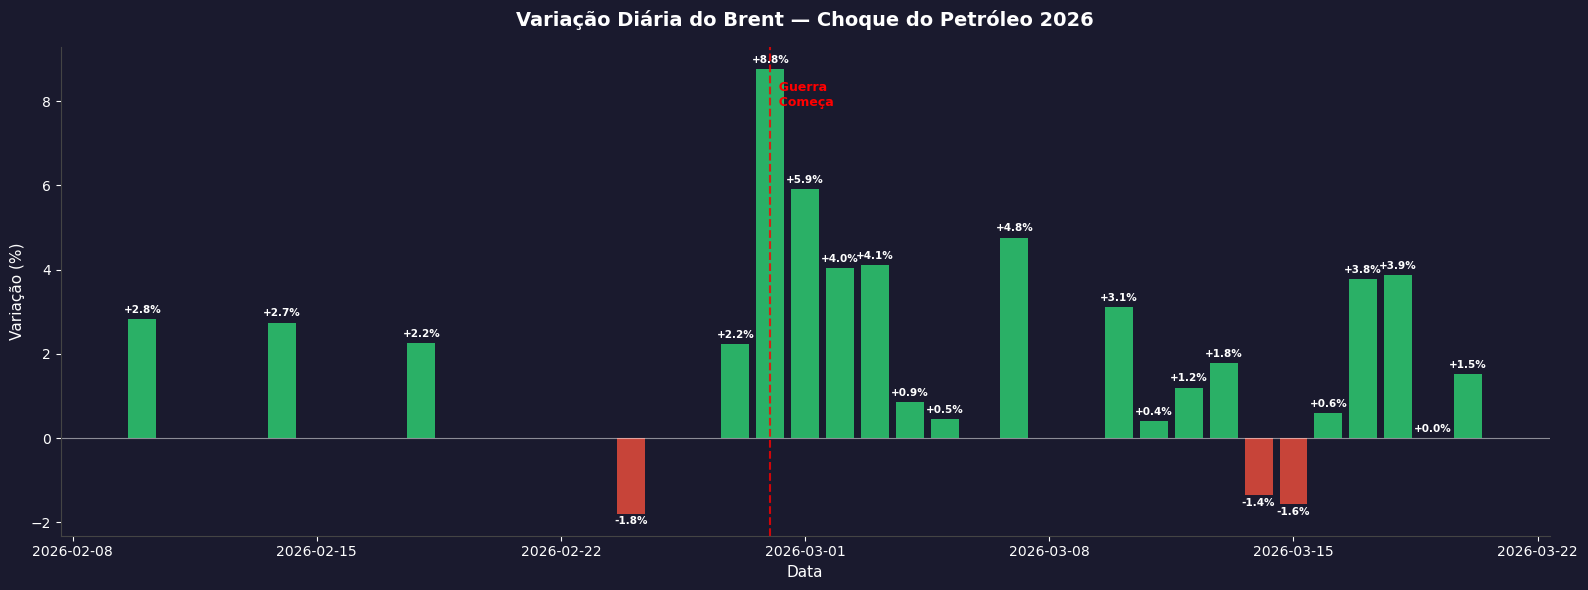

Gráfico 2 salvo!


In [27]:
# GRÁFICO 2 — Variação percentual diária do Brent
# Responde: quais foram os dias de maior movimento do mercado?

# Removendo o primeiro dia que tem NaN na variação
oil_var = oil.dropna(subset=['brent_daily_change_pct'])

# Definindo cor por sinal — verde para alta, vermelho para queda
cores_var = ['#2ECC71' if v > 0 else '#E74C3C' 
             for v in oil_var['brent_daily_change_pct']]

fig, ax = plt.subplots(figsize=(16, 6))

# Gráfico de barras — cada barra é um dia
bars = ax.bar(oil_var['date'], oil_var['brent_daily_change_pct'],
              color=cores_var, alpha=0.85, width=0.8)

# Linha de referência no zero
ax.axhline(y=0, color='white', linewidth=0.8, alpha=0.5)

# Linha vertical marcando o início da guerra
ax.axvline(x=pd.Timestamp('2026-02-28'), color='red',
           linestyle='--', linewidth=1.5, alpha=0.8)
ax.text(pd.Timestamp('2026-02-28'), ax.get_ylim()[1] * 0.85,
        '  Guerra\n  Começa', color='red', fontsize=9, fontweight='bold')

# Anotando o valor em cima de cada barra
for bar, val in zip(bars, oil_var['brent_daily_change_pct']):
    offset = 0.1 if val >= 0 else -0.3
    ax.text(bar.get_x() + bar.get_width() / 2, val + offset,
            f'{val:+.1f}%', ha='center', va='bottom',
            fontsize=7.5, color='white', fontweight='bold')

# Configurações visuais
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.spines['bottom'].set_color('#444')
ax.spines['left'].set_color('#444')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_title('Variação Diária do Brent — Choque do Petróleo 2026',
             fontsize=14, fontweight='bold', color='white', pad=15)
ax.set_xlabel('Data', fontsize=11)
ax.set_ylabel('Variação (%)', fontsize=11)

plt.tight_layout()
plt.savefig('grafico2_variacao_diaria.png', dpi=150,
            bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

print("Gráfico 2 salvo!")

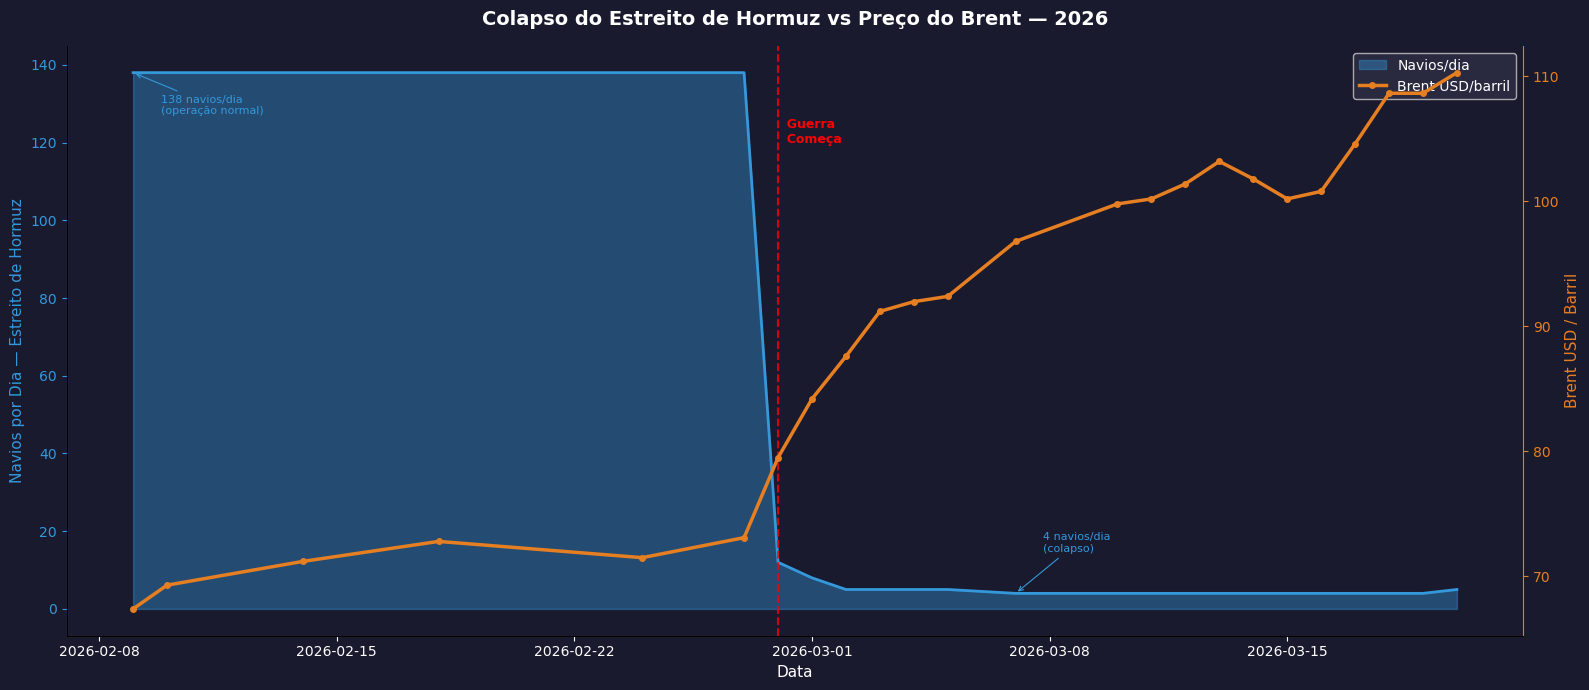

Gráfico 3 salvo!


In [28]:
# GRÁFICO 3 — Tráfego no Estreito de Hormuz vs Preço do Brent
# Responde: qual foi o impacto direto do fechamento do Estreito no preço?
# Dois eixos Y — esquerdo para navios, direito para o Brent

fig, ax1 = plt.subplots(figsize=(16, 7))

# Eixo esquerdo — número de navios (área preenchida)
ax1.fill_between(oil['date'], oil['strait_hormuz_daily_ships'],
                 alpha=0.4, color='#3498DB', label='Navios/dia')
ax1.plot(oil['date'], oil['strait_hormuz_daily_ships'],
         color='#3498DB', linewidth=2)
ax1.set_ylabel('Navios por Dia — Estreito de Hormuz', 
               fontsize=11, color='#3498DB')
ax1.tick_params(axis='y', colors='#3498DB')

# Eixo direito — preço do Brent
ax2 = ax1.twinx()
ax2.plot(oil['date'], oil['brent_usd_barrel'],
         color='#E67E22', linewidth=2.5,
         marker='o', markersize=4, label='Brent USD/barril')
ax2.set_ylabel('Brent USD / Barril', fontsize=11, color='#E67E22')
ax2.tick_params(axis='y', colors='#E67E22')

# Linha vertical marcando o início da guerra
ax1.axvline(x=pd.Timestamp('2026-02-28'), color='red',
            linestyle='--', linewidth=1.5, alpha=0.8)
ax1.text(pd.Timestamp('2026-02-28'), 120,
         '  Guerra\n  Começa', color='red', fontsize=9, fontweight='bold')

# Anotações dos extremos
ax1.annotate('138 navios/dia\n(operação normal)',
             xy=(pd.Timestamp('2026-02-09'), 138),
             xytext=(20, -30), textcoords='offset points',
             fontsize=8, color='#3498DB',
             arrowprops=dict(arrowstyle='->', color='#3498DB', lw=0.8))

ax1.annotate('4 navios/dia\n(colapso)',
             xy=(pd.Timestamp('2026-03-07'), 4),
             xytext=(20, 30), textcoords='offset points',
             fontsize=8, color='#3498DB',
             arrowprops=dict(arrowstyle='->', color='#3498DB', lw=0.8))

# Configurações visuais
ax1.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')
ax1.tick_params(axis='x', colors='white')
ax1.spines['bottom'].set_color('#444')
ax1.spines['left'].set_color('#3498DB')
ax1.spines['top'].set_visible(False)
ax2.spines['right'].set_color('#E67E22')
ax2.spines['top'].set_visible(False)
ax1.xaxis.label.set_color('white')
ax1.set_xlabel('Data', fontsize=11)

# Legendas dos dois eixos combinadas
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           facecolor='#2d2d44', labelcolor='white', fontsize=10)

ax1.set_title('Colapso do Estreito de Hormuz vs Preço do Brent — 2026',
              fontsize=14, fontweight='bold', color='white', pad=15)

plt.tight_layout()
plt.savefig('grafico3_hormuz_brent.png', dpi=150,
            bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

print("Gráfico 3 salvo!")

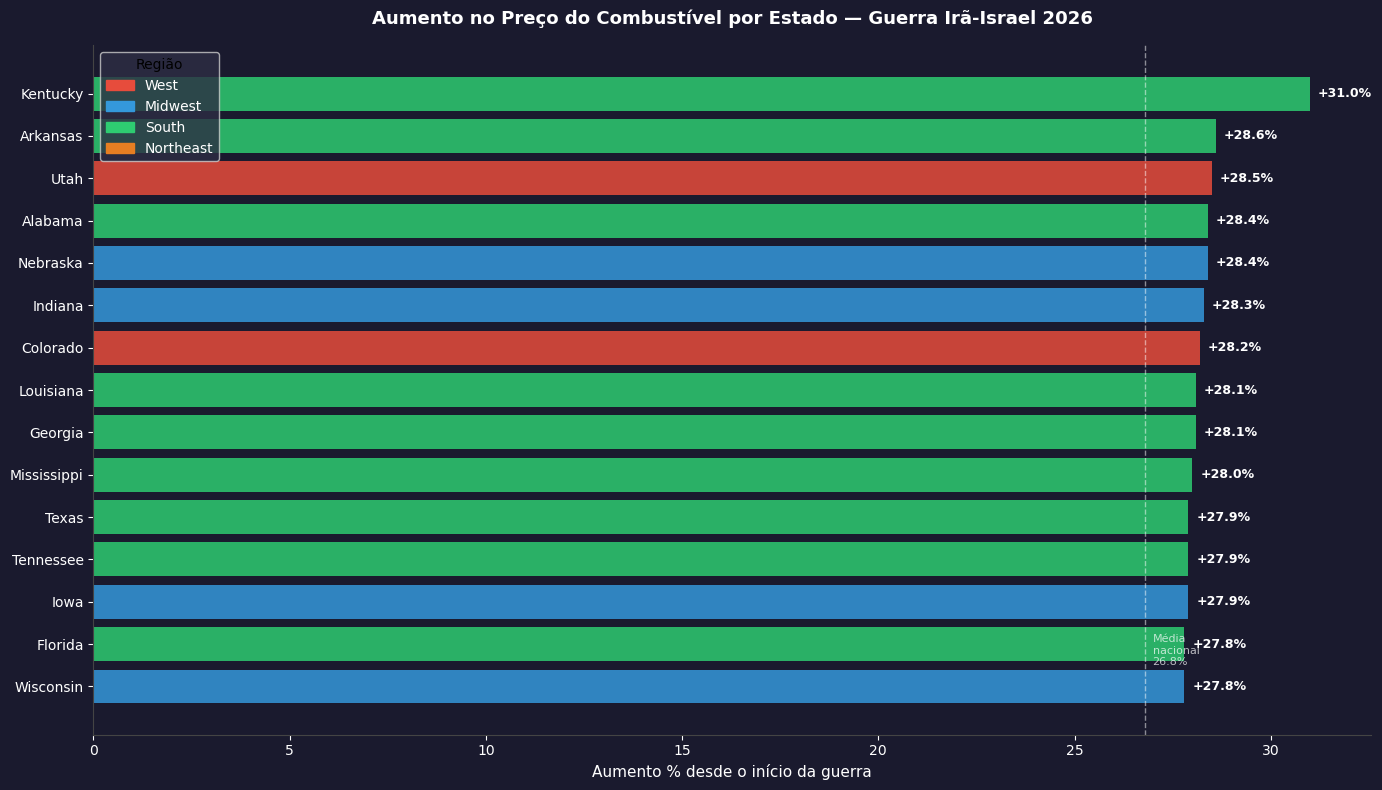

Gráfico 4 salvo!


In [29]:
# GRÁFICO 4 — Top 15 estados com maior aumento no preço do combustível
# Responde: quais regiões dos EUA foram mais impactadas?

# Ordenando os 15 estados com maior aumento percentual desde a guerra
top15 = gas.nlargest(15, 'pct_increase_since_war').sort_values('pct_increase_since_war')

# Mapeando cor por região
cores_regiao = {
    'West'     : '#E74C3C',
    'Midwest'  : '#3498DB',
    'South'    : '#2ECC71',
    'Northeast': '#E67E22'
}
cores_barras = [cores_regiao.get(r, '#95A5A6') for r in top15['region']]

fig, ax = plt.subplots(figsize=(14, 8))

# Barras horizontais — mais legíveis para listas de estados
bars = ax.barh(top15['state'], top15['pct_increase_since_war'],
               color=cores_barras, alpha=0.85)

# Anotando o valor no final de cada barra
for bar, val in zip(bars, top15['pct_increase_since_war']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
            f'+{val:.1f}%', va='center', fontsize=9,
            color='white', fontweight='bold')

# Legenda de regiões manual
from matplotlib.patches import Patch
legenda = [Patch(color=cor, label=regiao) 
           for regiao, cor in cores_regiao.items()]
ax.legend(handles=legenda, facecolor='#2d2d44',
          labelcolor='white', fontsize=10, title='Região',
          title_fontsize=10)

# Linha de referência na média nacional
media_nacional = gas['pct_increase_since_war'].mean()
ax.axvline(x=media_nacional, color='white', linestyle='--',
           linewidth=1, alpha=0.5)
ax.text(media_nacional + 0.2, 0.5, f'Média\nnacional\n{media_nacional:.1f}%',
        color='white', fontsize=8, alpha=0.7)

# Configurações visuais
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.spines['bottom'].set_color('#444')
ax.spines['left'].set_color('#444')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_title('Aumento no Preço do Combustível por Estado — Guerra Irã-Israel 2026',
             fontsize=13, fontweight='bold', color='white', pad=15)
ax.set_xlabel('Aumento % desde o início da guerra', fontsize=11)

plt.tight_layout()
plt.savefig('grafico4_estados.png', dpi=150,
            bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

print("Gráfico 4 salvo!")

In [31]:
---

## Conclusões e Insights

### O que os dados revelaram sobre o Choque do Petróleo de 2026

**Insight 1 — Velocidade do choque foi sem precedentes**
O Brent saiu de $73 para $110 em apenas 21 dias — uma alta de +50.9%.
Para comparação, o choque de 2022 levou 3 meses para atingir variação similar.
O fechamento imediato do Estreito de Hormuz foi o fator decisivo.

**Insight 2 — Estreito de Hormuz: de 138 para 4 navios/dia**
O tráfego no Estreito colapsou 97% em 24 horas após o início da guerra.
A correlação inversa com o Brent é direta e imediata — cada navio a menos
significou mais pressão no preço do petróleo global.

**Insight 3 — Semana 1 foi a mais volátil, não a mais cara**
Os maiores movimentos diários ocorreram entre 28/fev e 04/mar,
com volatilidade de 5 a 7 pontos. Nas semanas seguintes o preço
continuou subindo, porém de forma mais gradual e consistente.

**Insight 4 — Sul e Midwest americanos foram os mais impactados**
Kentucky (+31%), Arkansas (+28.6%) e estados do Sul lideraram
o ranking de aumento no combustível — regiões com menor
infraestrutura de refino local absorveram mais o choque.

---

### Ferramentas utilizadas
`Python` · `Pandas` · `NumPy` · `Matplotlib` · `Seaborn`

### Fonte dos dados
Dataset público disponível no Kaggle —
*Iran War Oil Shock 2026 | Brent & Gas Tracker*

SyntaxError: invalid character '—' (U+2014) (3595615174.py, line 7)